In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load customer dataset

data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

# Remove rows with missing TotalCharges
data = data.dropna(subset=["TotalCharges"])

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

Dataset loaded successfully!
Dataset shape: (7032, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
# Select relevant numerical features

features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X_cluster = data[features].copy()

print("Selected features:")
print(X_cluster.head())

print("\nFeature shape:", X_cluster.shape)

Selected features:
   tenure  MonthlyCharges  TotalCharges
0       1           29.85         29.85
1      34           56.95       1889.50
2       2           53.85        108.15
3      45           42.30       1840.75
4       2           70.70        151.65

Feature shape: (7032, 3)


In [4]:
# Standardize features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

print("Features standardized successfully!")
print("Scaled data shape:", X_scaled.shape)

Features standardized successfully!
Scaled data shape: (7032, 3)


In [5]:
# Experiment with different numbers of clusters

cluster_results = []

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    cluster_results.append({
        "Number of Clusters": k,
        "Silhouette Score": score
    })

cluster_results = pd.DataFrame(cluster_results)

print(cluster_results)

   Number of Clusters  Silhouette Score
0                   2          0.479524
1                   3          0.451513
2                   4          0.472085
3                   5          0.443269
4                   6          0.437604


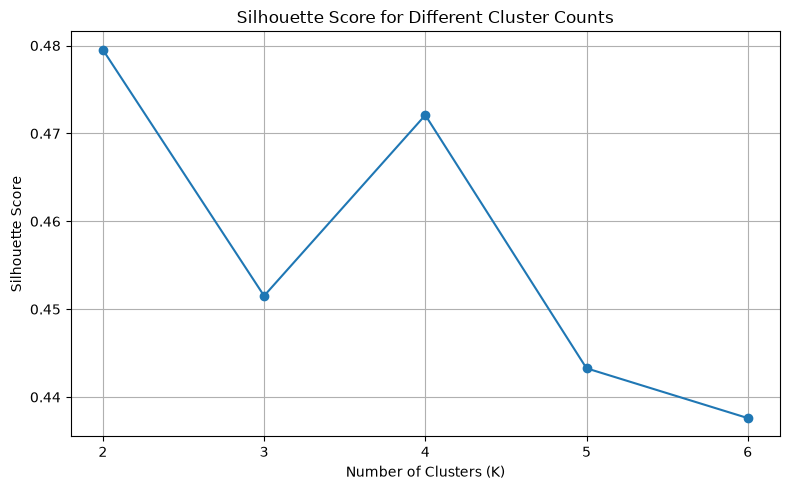

In [6]:
# Visualize silhouette scores

plt.figure(figsize=(8, 5))

plt.plot(
    cluster_results["Number of Clusters"],
    cluster_results["Silhouette Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Cluster Counts")
plt.xticks(range(2, 7))
plt.grid(True)

plt.tight_layout()
plt.savefig(
    "silhouette_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
# Select K based on the highest silhouette score

best_k = int(
    cluster_results.loc[
        cluster_results["Silhouette Score"].idxmax(),
        "Number of Clusters"
    ]
)

best_score = cluster_results["Silhouette Score"].max()

print("Selected number of clusters:", best_k)
print(f"Silhouette Score: {best_score:.4f}")

Selected number of clusters: 2
Silhouette Score: 0.4795


In [8]:
# Train final K-Means model

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

data["Cluster"] = kmeans_final.fit_predict(X_scaled)

print("K-Means clustering completed!")
print("\nCustomers in each cluster:")
print(data["Cluster"].value_counts().sort_index())

K-Means clustering completed!

Customers in each cluster:
Cluster
0    2360
1    4672
Name: count, dtype: int64


In [9]:
# Analyze customer characteristics by cluster

cluster_summary = data.groupby("Cluster")[features].mean().round(2)

print("Customer Segment Summary:")
print(cluster_summary)

Customer Segment Summary:
         tenure  MonthlyCharges  TotalCharges
Cluster                                      
0         56.87           89.76       5084.99
1         20.07           52.19        868.07


In [10]:
# Count customers in each cluster

cluster_counts = (
    data["Cluster"]
    .value_counts()
    .sort_index()
)

print("Customers per cluster:")
print(cluster_counts)

Customers per cluster:
Cluster
0    2360
1    4672
Name: count, dtype: int64


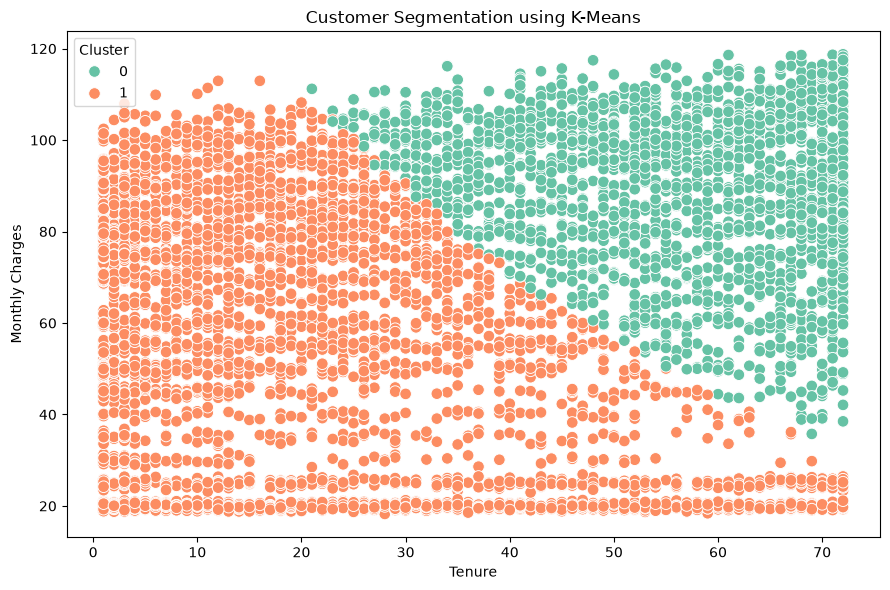

In [11]:
# Visualize customer segments

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=data,
    x="tenure",
    y="MonthlyCharges",
    hue="Cluster",
    palette="Set2",
    s=70
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.legend(title="Cluster")

plt.tight_layout()

plt.savefig(
    "customer_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
# Create business insight report

business_insights = []

for cluster in sorted(data["Cluster"].unique()):
    row = cluster_summary.loc[cluster]

    insight = (
        f"Cluster {cluster}: "
        f"Average tenure = {row['tenure']:.2f} months, "
        f"average monthly charges = ${row['MonthlyCharges']:.2f}, "
        f"average total charges = ${row['TotalCharges']:.2f}, "
        f"customer count = {cluster_counts.loc[cluster]}."
    )

    business_insights.append(insight)

print("Business Insights")
print("=" * 50)

for insight in business_insights:
    print(insight)

Business Insights
Cluster 0: Average tenure = 56.87 months, average monthly charges = $89.76, average total charges = $5084.99, customer count = 2360.
Cluster 1: Average tenure = 20.07 months, average monthly charges = $52.19, average total charges = $868.07, customer count = 4672.


In [13]:
# Save cluster analysis reports

cluster_summary.to_csv(
    "customer_segment_summary.csv"
)

cluster_counts.to_csv(
    "customer_segment_counts.csv"
)

cluster_results.to_csv(
    "cluster_count_comparison.csv",
    index=False
)

with open("business_insights.txt", "w") as file:
    for insight in business_insights:
        file.write(insight + "\n")

print("Business insight reports saved successfully!")

Business insight reports saved successfully!
